# FLIM Analysis of EGFP and Maroon: Isolated Protein and Transiently Expressed in U2OS

## Loading Necessary Script

In [1]:
import os
import sys
import io
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt

from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (16, 12)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16

import pq_decoding_functions as pq
import flim_fitting_functions as fit

## Fitting Simulated Data

In [2]:
time_axis = pq.make_time_axis(
    global_resolution = 1/19450000,
    resolution = 1.6E-11,
)



## EGFP
### Transient Expression

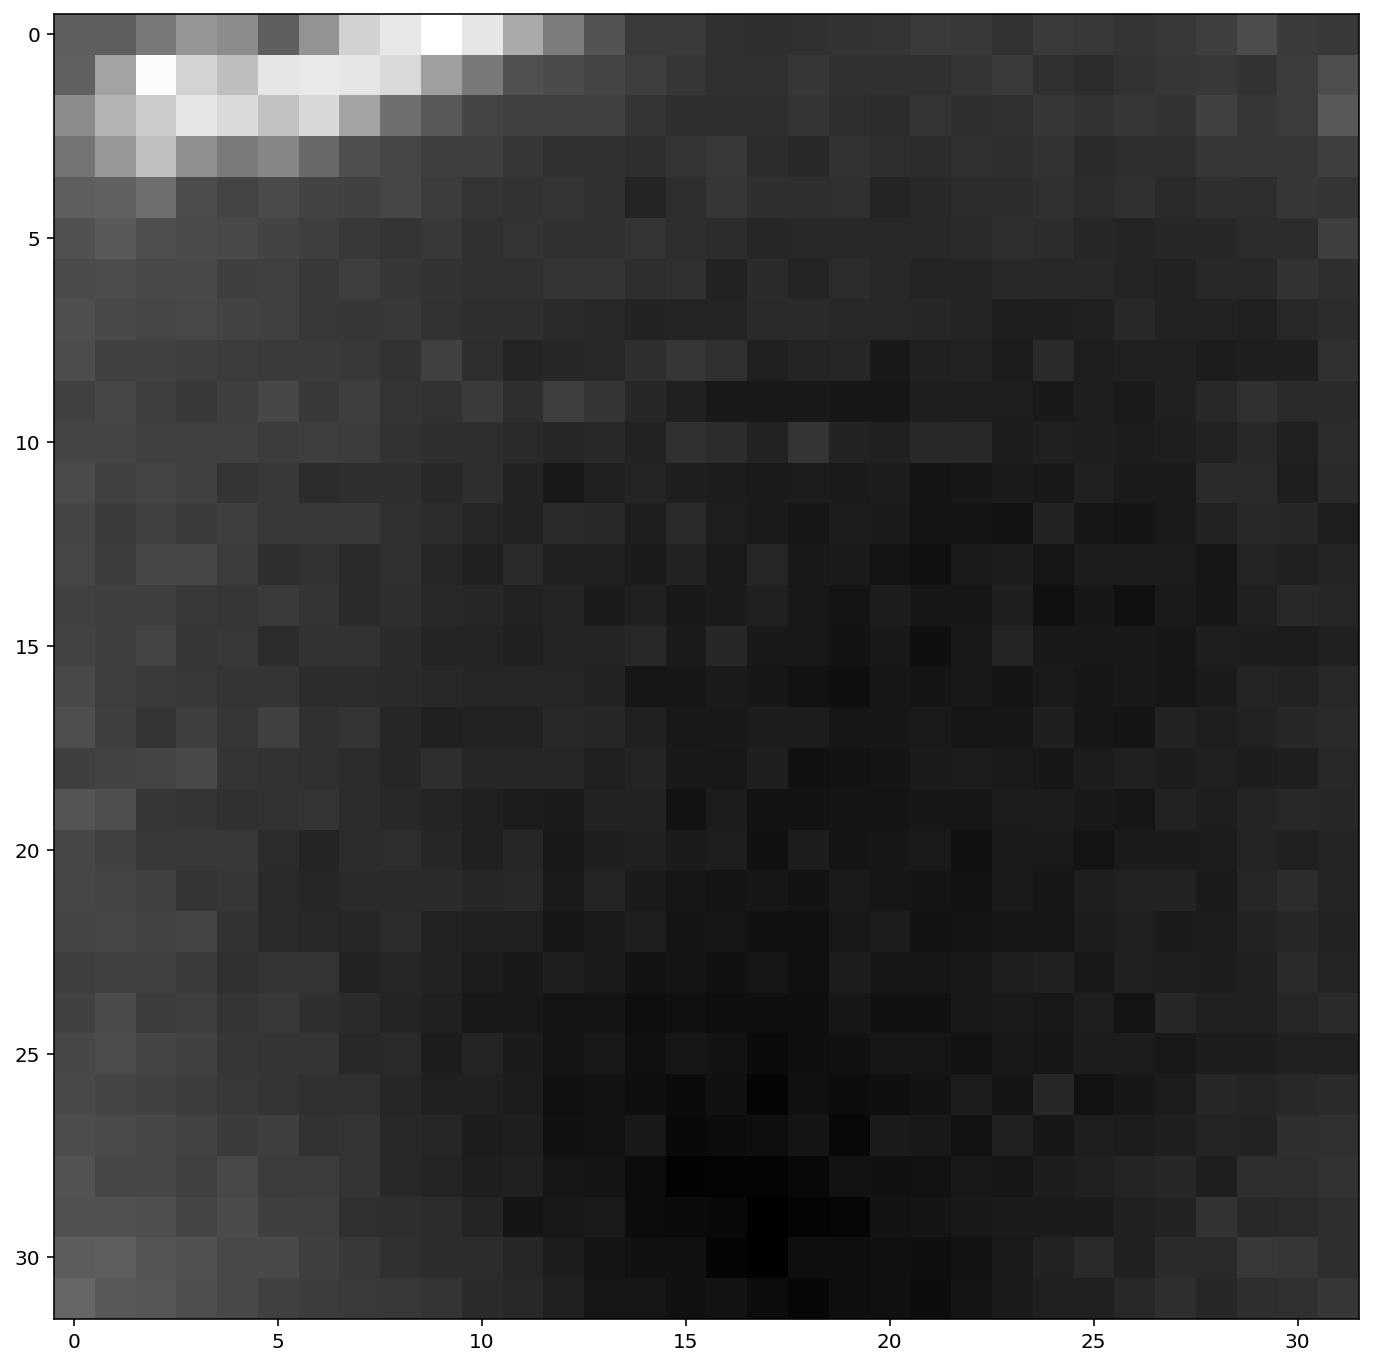

In [17]:
#EGFP_cell_data, EGFP_cell_meta = pq.readPTUData(
#    path = '../../../FLIM Data/Praktikum_Biochemie/raw_data/IsolatedFP_200310_EGFP_Maroon.sptw/iFP_200310_Kontrolle_Sulforhodamine_10µM_1_2_1.ptu'
#)

#EGFP_cell_data, EGFP_cell_meta = pq.readPTUData(
#    path = '/home/agbp/Desktop/Praktikum_Biochemie/raw_data/'
#)



#EGFP_cell_flimarray, EGFP_image = pq.buildFLIMArray(
#    recordarray = EGFP_cell_data,
#    channel = 1,
#    linesinfile = pq.countLines(EGFP_cell_data),
#    pixelsx = EGFP_cell_meta['PixelsX'],
#    pixelsy = EGFP_cell_meta['PixelsY'],
#    globRes = EGFP_cell_meta['GlobalResolution'],
#    timeRes = EGFP_cell_meta['Resolution'],
#    spatialBinning = 3,
#    temporalBinning = 1
#)


ptu_path = '/home/agbp/Desktop/Praktikum_Biochemie/raw_data/IsolatedFP_200310_EGFP_Maroon.sptw/iFP_200310_EGFP+Glycerol_1_1_1.ptu'
#ptu_path = '/home/agbp/Desktop/Coumarin6_in_EtOH_2_1.ptu'

EGFP_cell_fa, EGFP_cell_ii, time_axis= pq.load_flim_data(
    path = ptu_path,
    channel = 1,
    spatialBinning = 4,
    temporalBinning = 0
)

EGFP_decay = fit.sum_up_decay(EGFP_cell_fa)
EGFP_decay = EGFP_cell_fa [2, 2, :]

plt.imshow(EGFP_cell_ii, cmap = 'gray')
plt.show()

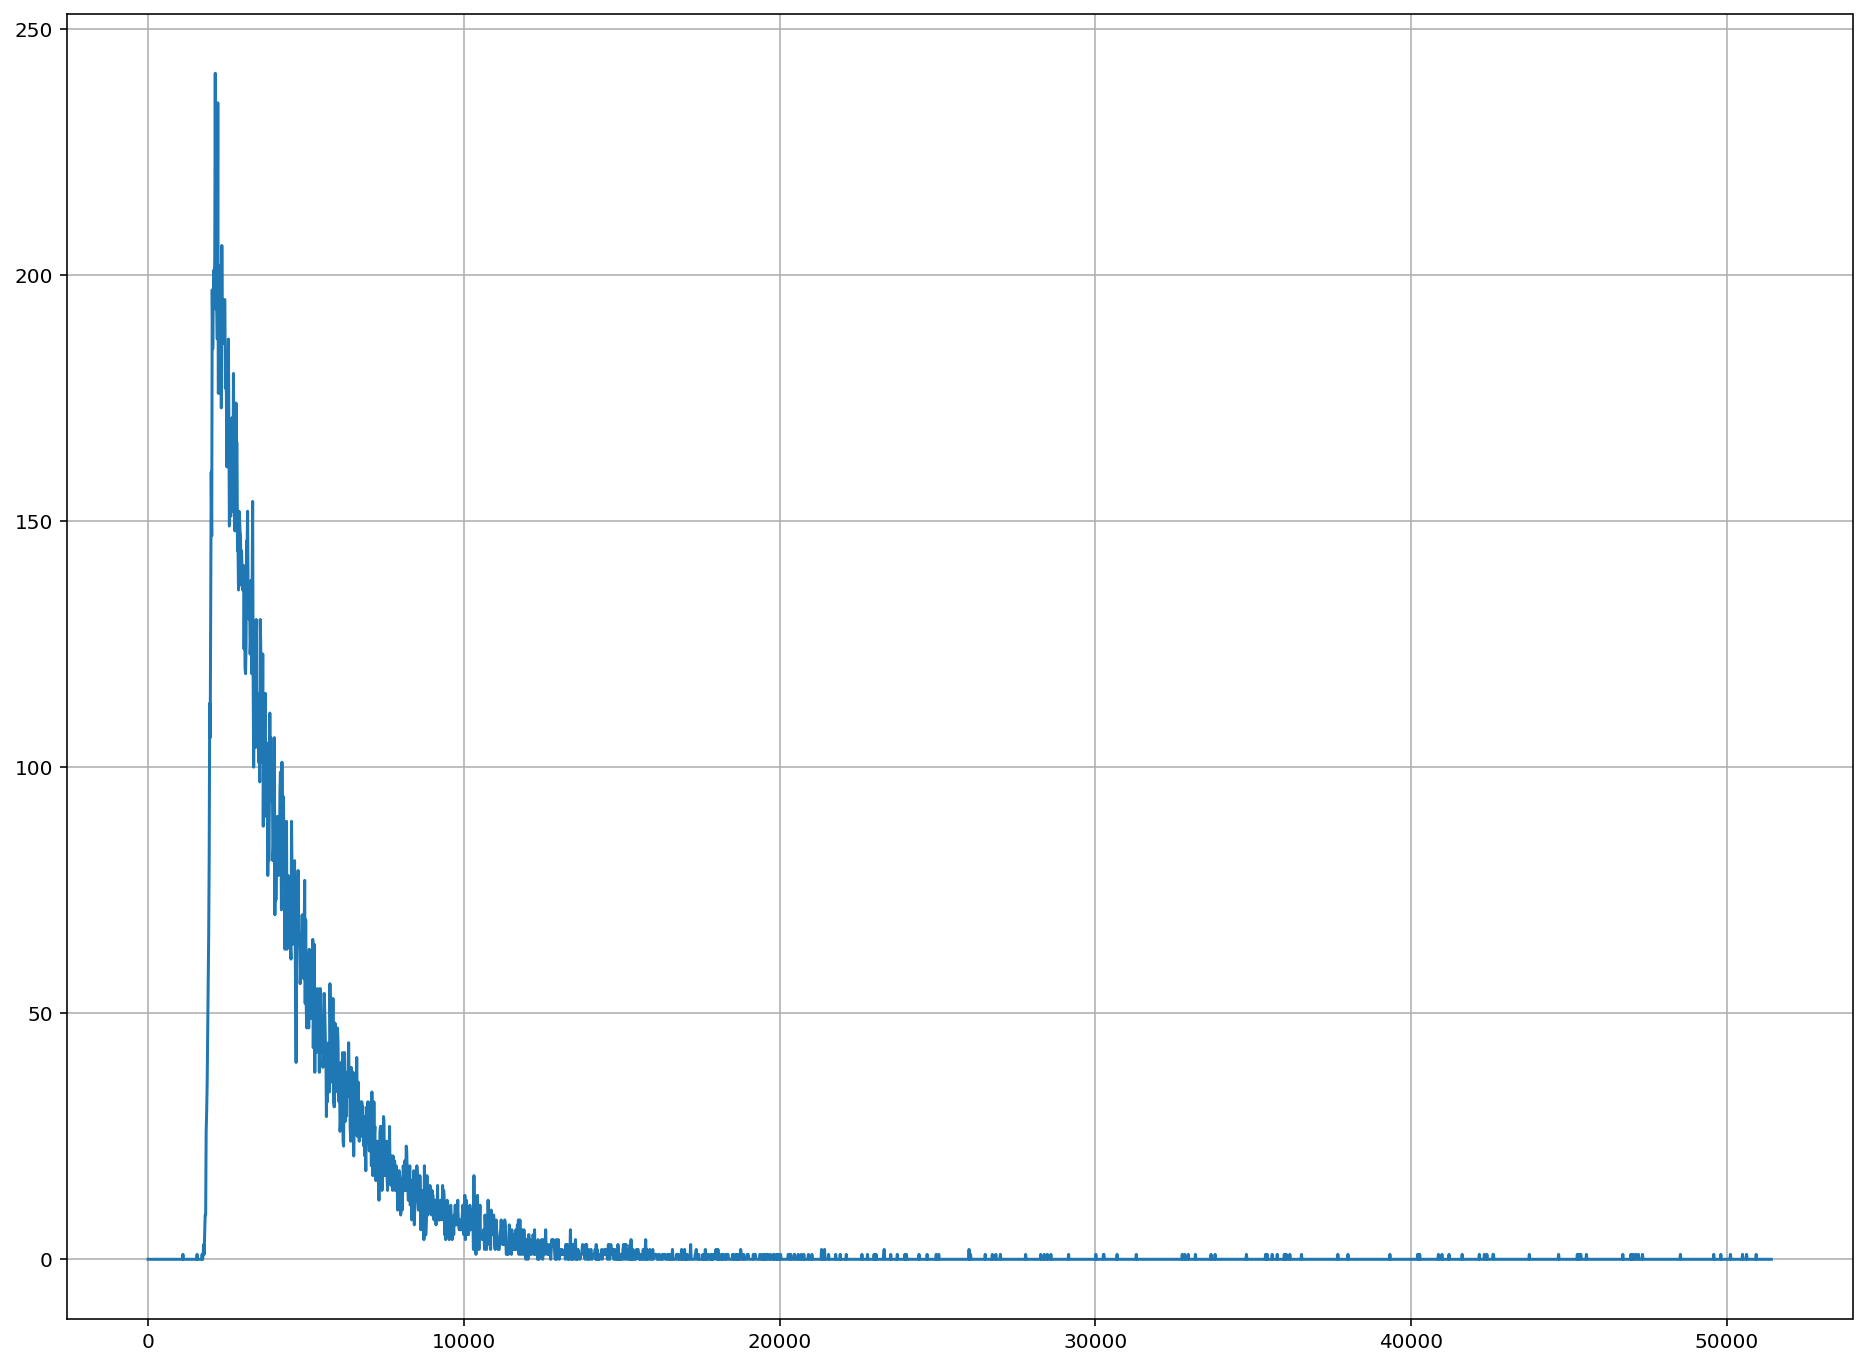

In [19]:
plt.plot(time_axis, EGFP_decay)
plt.grid()
plt.show()

In [20]:
parameter_names, estimated_parameters, parameter_bounds = fit.make_start_parameters(
    offset = 2,
    amplitude = 5,
    Scatter_amplitude = 0,
    #tau = 200,
    #IRF_sigma = 25
)

EGFP_fit = fit.fit_decay(
    EGFP_decay,
    time_axis,
    estimated_parameters,
    parameter_bounds#,
    #cutoff = 350,
    #minimization_method = 'SLSQP'
)


/home/agbp/anaconda3/lib/python3.7/site-packages/scipy/optimize/_minimize.py:516: RuntimeWarning: Method Nelder-Mead cannot handle constraints nor bounds.
  RuntimeWarning)
/home/agbp/Documents/Repos/PhasorFLIM/notebooks/flim_fitting_functions.py:137: RuntimeWarning: divide by zero encountered in log
  data * np.log(data / fitted) - (data - fitted)
/home/agbp/Documents/Repos/PhasorFLIM/notebooks/flim_fitting_functions.py:137: RuntimeWarning: invalid value encountered in multiply
  data * np.log(data / fitted) - (data - fitted)


/home/agbp/Documents/Repos/PhasorFLIM/notebooks/flim_fitting_functions.py:99: RuntimeWarning: divide by zero encountered in true_divide
  weights = 1.0 / np.sqrt(data, where = (data != 0))
/home/agbp/Documents/Repos/PhasorFLIM/notebooks/flim_fitting_functions.py:99: RuntimeWarning: overflow encountered in true_divide
  weights = 1.0 / np.sqrt(data, where = (data != 0))
/home/agbp/Documents/Repos/PhasorFLIM/notebooks/flim_fitting_functions.py:100: RuntimeWarning: divide by zero encountered in double_scalars
  weights[np.where(data == 0)] = 1.0 / np.sqrt(estimate_background(data))


Reduced Chi-Squared: 0.9208664914071414


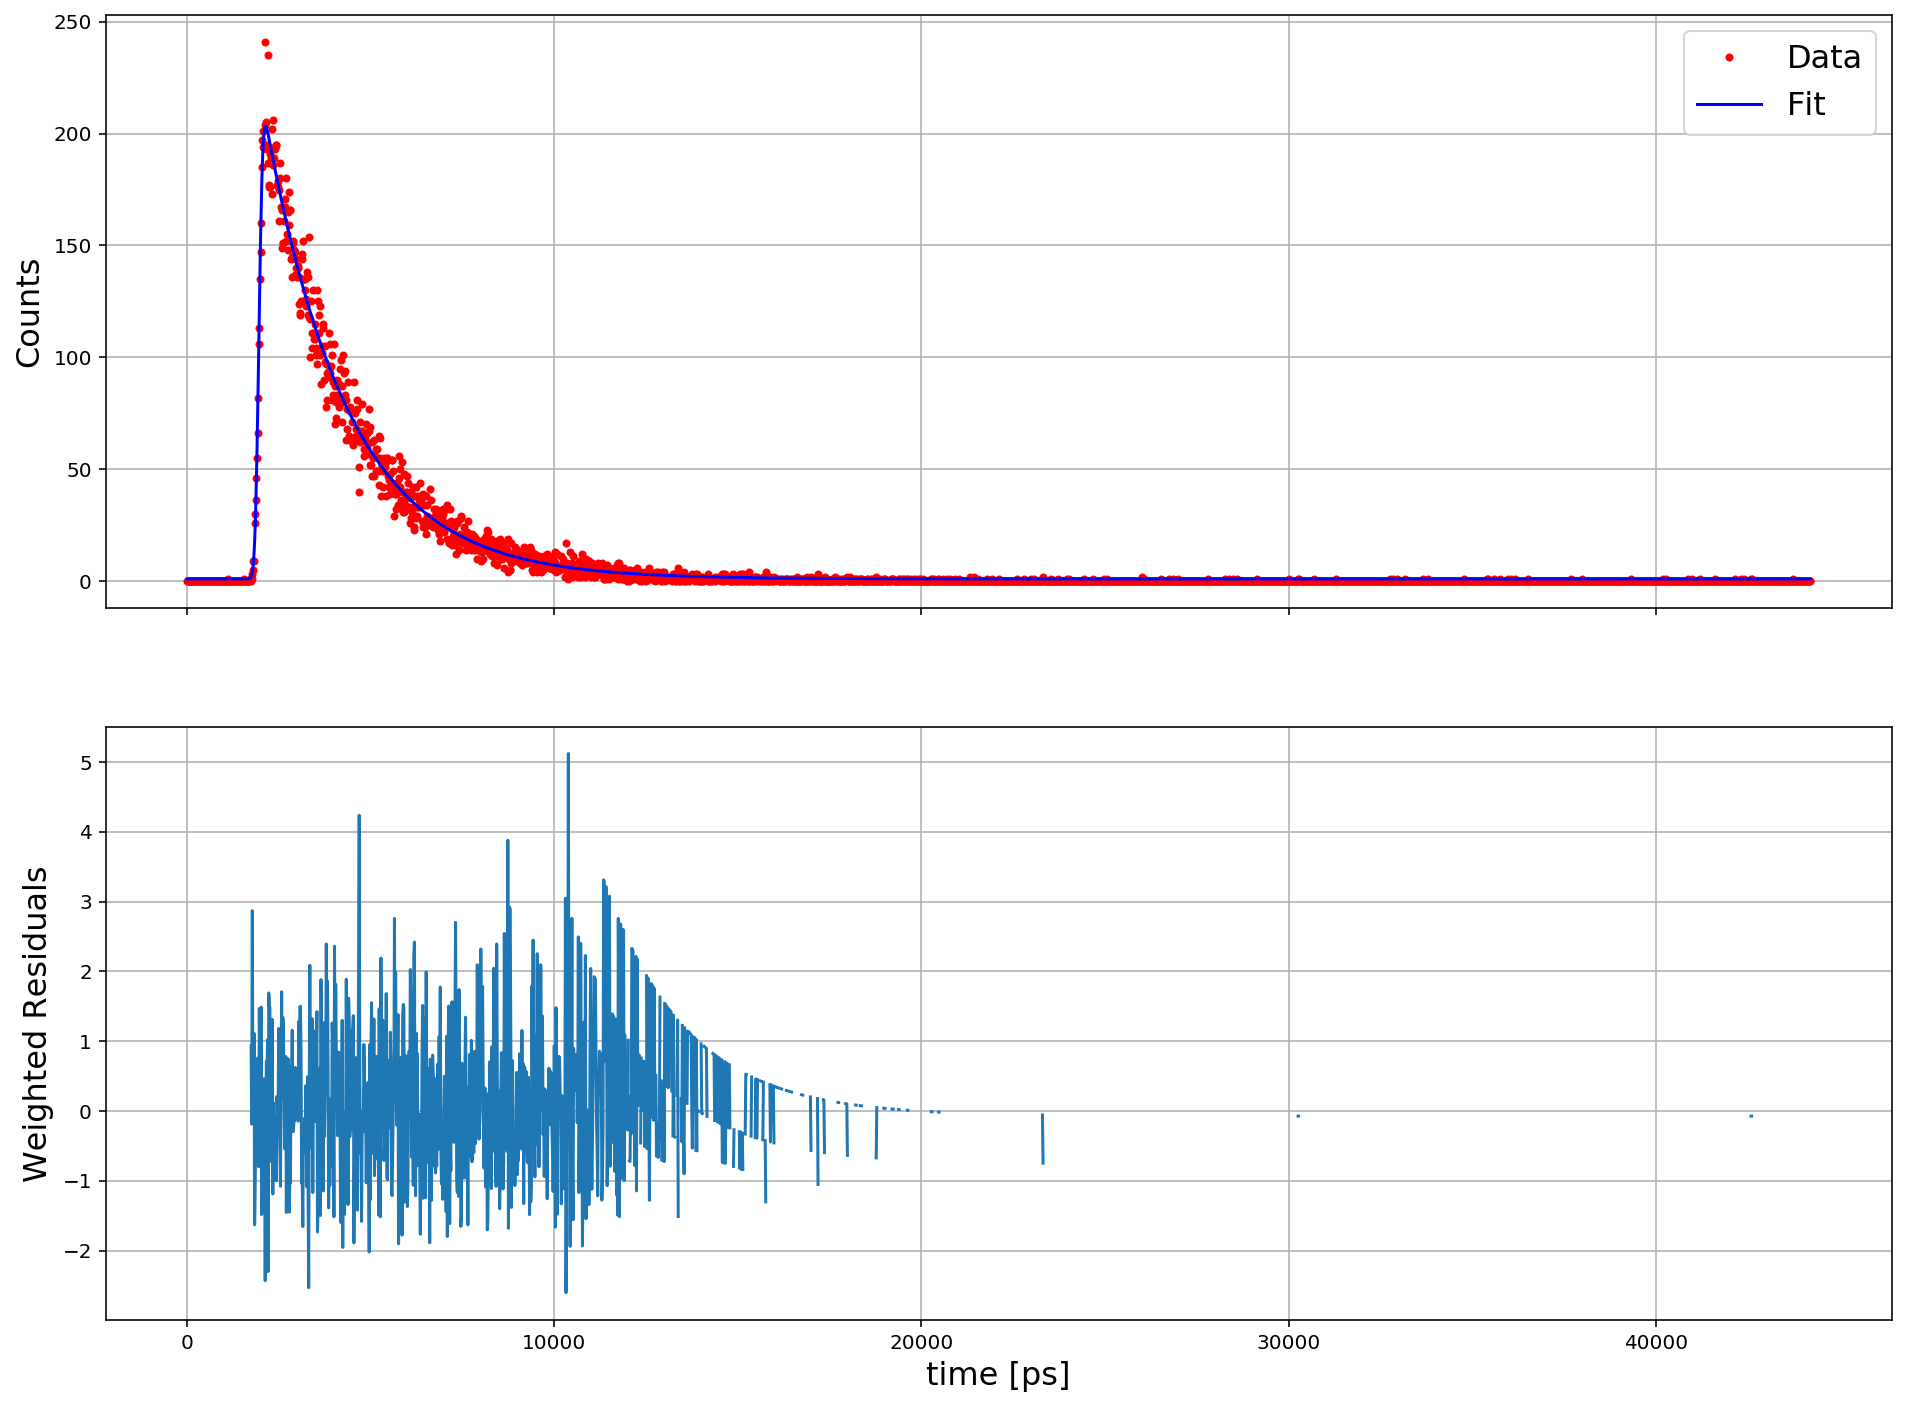

offset 		 0.9267886123922504
amplitude 		 2.5091854348866534
tau 		 2242.7604917506715
IRF_mu 		 1964.5607927321453
IRF_sigma 		 57.680040968140844
Scatter_amp 		 -0.0076540915491599415
Scatter_mu 		 4032.0690089203363


In [21]:
fit.plot_fit(EGFP_decay, time_axis, EGFP_fit, cutoff = 450, scale = 'linear')

for i in range(0, len(parameter_names)):
    print(parameter_names[i], '\t\t', EGFP_fit['x'][i])